In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import anndata as ad
import scipy.sparse as sp
import re
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.stats import ttest_ind, t, sem
from scipy.stats import mannwhitneyu
import matplotlib.colors as mcolors

cm = 1/2.54  # inches to cm

gray_to_red = mcolors.LinearSegmentedColormap.from_list("gray_to_red", [(0.5, 0.5, 0.5), (1, 0, 0)])

def plot_gene_expression_summary(adata, top_genes, category, title=None, ax=None):
    # Préparation des données fondues
    melted = (
        adata[:, top_genes].to_df()
        .assign(**{category: adata.obs[category].values})
        .melt(id_vars=category, var_name="gene", value_name="expression")
    )

    # Détection des niveaux de groupe
    group_levels = (
        list(adata.obs[category].cat.categories)
        if hasattr(adata.obs[category], "cat")
        else sorted(adata.obs[category].unique())
    )

    # Calcul des statistiques
    summary_stats = (
        melted.groupby(["gene", category], observed=False)
        .agg(mean_expression=("expression", "mean"),
             count=("expression", "count"),
             std=("expression", "std"))
        .reset_index()
    )

    summary_stats["std"] = summary_stats["std"].fillna(0.0)
    summary_stats["sem"] = summary_stats["std"] / np.sqrt(summary_stats["count"].clip(lower=1))
    df_dof = (summary_stats["count"] - 1).clip(lower=1)
    summary_stats["ci95"] = t.ppf(0.975, df_dof) * summary_stats["sem"]
    summary_stats.loc[summary_stats["count"] <= 1, "ci95"] = 0.0

    # Pivots
    mean_pivot = (
        summary_stats.pivot(index="gene", columns=category, values="mean_expression")
        .reindex(top_genes)
        .reindex(columns=group_levels)
        .fillna(0.0)
    )
    ci_pivot = (
        summary_stats.pivot(index="gene", columns=category, values="ci95")
        .reindex(top_genes)
        .reindex(columns=group_levels)
        .fillna(0.0)
    )

    # Tests Mann-Whitney pour deux groupes
    pvalues = {}
    if len(group_levels) == 2:
        for gene in top_genes:
            gene_vals = melted[melted["gene"] == gene]
            grp1 = gene_vals[gene_vals[category] == group_levels[0]]["expression"]
            grp2 = gene_vals[gene_vals[category] == group_levels[1]]["expression"]
            _, pval = mannwhitneyu(grp1, grp2, alternative='two-sided')
            pvalues[gene] = pval


    def star_from_pvalue(p):
        if p < 1e-4:
            return "****"
        if p < 1e-3:
            return "***"
        if p < 1e-2:
            return "**"
        if p < 5e-2:
            return "*"
        return ""

    # Graphique
    x = np.arange(len(top_genes))
    bar_width = 0.35

    if ax is None:
        fig_bar, ax_bar = plt.subplots(figsize=(14, 6))
    else:
        ax_bar = ax
    
    # Définir les couleurs pour True (vert) et False (rouge)
    color_map = {"True": 'green', "False": 'red'}
        
    for idx, level in enumerate(group_levels):
        offsets = (idx - (len(group_levels) - 1) / 2) * bar_width
        means = mean_pivot[level].to_numpy()
        cis = ci_pivot[level].to_numpy()
        color = color_map.get(level, 'gray')
        ax_bar.bar(
            x + offsets,
            means,
            width=bar_width,
            yerr=cis,
            capsize=5,
            label=level,
            alpha=0.8,
            color=color
        )

    if len(group_levels) == 2:
        max_height = (mean_pivot + ci_pivot).values.max()
        for gene_idx, gene in enumerate(top_genes):
            pval = pvalues.get(gene)
            stars = star_from_pvalue(pval) if pval is not None else ""
            if stars:
                positions = x[gene_idx] + np.array(
                    [(i - (len(group_levels) - 1) / 2) * bar_width for i in range(len(group_levels))]
                )
                top_vals = mean_pivot.loc[gene, group_levels].to_numpy() + ci_pivot.loc[gene, group_levels].to_numpy()
                y = top_vals.max() + 0.15 * max_height / 6
                h = 0.05 * max_height
                ax_bar.plot([positions[0], positions[0], positions[1], positions[1]],
                            [y, y + h, y + h, y], color="black", linewidth=1)
                ax_bar.text(positions.mean(), y + h + 0.02 * max_height, stars,
                            ha="center", va="bottom", fontsize=12)
                

    ax_bar.set_ylabel("Expression")
    if title:
        ax_bar.set_title(title)
    else:
        ax_bar.set_title(f"Expression of top genes by {category} (95% CI)")
    ax_bar.set_xticks(x)
    ax_bar.set_xticklabels(top_genes, rotation=45, ha="right")
    ax_bar.legend(title=category)
    ax_bar.grid(axis="y", linestyle="--", alpha=0.3)
    ax_bar.set_ylim(0, (mean_pivot + ci_pivot).values.max() * 1.5)

    if ax is None:
        ax_bar.set_xlabel("Gene")
        plt.show()
    else:
        return ax_bar

In [2]:
adata_sigma = sc.read_h5ad("/mnt/projects_tn03/Data_MK/article/results_fortman/merge.h5ad")
adata_author = sc.read_h5ad("/mnt/projects_tn03/Data_MK/article/mk_fortman/BloodAdvances_COVID_Megakaryocytes.h5ad")

adata_sigma.obs_names = [re.sub(r"-Blood.*", "", name) for name in adata_sigma.obs_names]

In [3]:
adata_sumry = ad.AnnData(adata_author.X, var=adata_author.var)
adata_sumry.obs_names = adata_author.obs_names

# Add UMAP coordinates
adata_sumry.obsm["X_umap"] = adata_author.obsm["X_umap"]

# Add counts table
adata_sumry.layers["raw"] = adata_author.layers["counts"]

# Add obs table
adata_sumry.obs["donor"] = adata_author.obs["sample"]
adata_sumry.obs["phase"] = adata_author.obs["phase"]
adata_sumry.obs["dataset"] = adata_author.obs["dataset"]
adata_sumry.obs["celltype"] = adata_author.obs["clusters"]

adata_sumry.obs["score"] = 0.0
adata_sumry.obs.loc[adata_sigma.obs_names, "score"] = adata_sigma.obs["score"].values

proba_cols = [col for col in adata_sigma.obs.columns if col.startswith("proba_")]
for prob in proba_cols:
    adata_sumry.obs[prob] = 0.0
    adata_sumry.obs.loc[adata_sigma.obs_names, prob] = adata_sigma.obs[prob].values

sc.pp.normalize_total(adata_sumry, target_sum=1e6)
sc.pp.log1p(adata_sumry)
adata_sumry.layers["log1p"] = adata_sumry.X

# Score plot

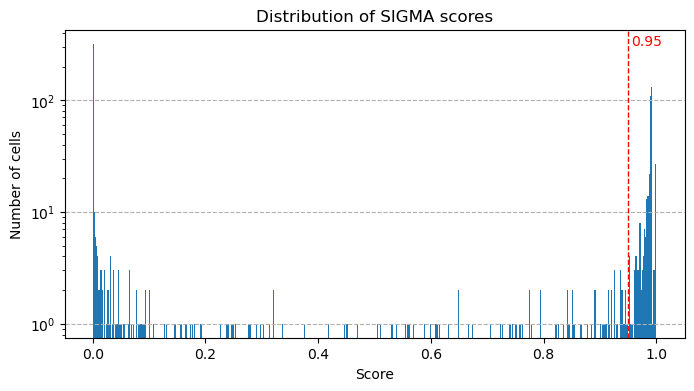

In [9]:
seuil = 0.95

fig, ax = plt.subplots(figsize=(8,4))

ax.hist(adata_sigma.obs["score"], bins=500)
ax.set_xlabel("Score")
ax.set_ylabel("Number of cells")
ax.set_yscale("log")
ax.set_title("Distribution of SIGMA scores")
ax.grid(axis='y', linestyle='--')
ax.axvline(seuil, color='red', linestyle='--', linewidth=1)
ax.text(seuil + 0.005, ax.get_ylim()[1]*0.9, str(seuil), color='red', ha='left', va='top')

fig.savefig("figures/fortman_Score.svg", bbox_inches="tight", dpi=300)
plt.show()

In [10]:
MK_found_by_sigma = adata_sumry.obs["score"] >= 0.98
adata_sumry.obs["Identified by SIGMA"] = MK_found_by_sigma.astype(str)

adata_sumry.obs["Identified by SIGMA"] = pd.Categorical(
    adata_sumry.obs["Identified by SIGMA"],
    categories=["True", "False"],
    ordered=True
)

mk_author = adata_sumry[adata_sumry.obs["celltype"] == "megakaryocytes"]
mk_sigma = adata_sumry[adata_sumry.obs["Identified by SIGMA"] == "True"]

sc.tl.pca(mk_author)
sc.pp.neighbors(mk_author)
sc.tl.umap(mk_author)

sc.tl.pca(mk_sigma)
sc.pp.neighbors(mk_sigma)
sc.tl.umap(mk_sigma)

/home/lemgui01/.miniconda3/envs/SIGMA/lib/python3.10/site-packages/scanpy/preprocessing/_pca/__init__.py:379: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = X_pca
/home/lemgui01/.miniconda3/envs/SIGMA/lib/python3.10/site-packages/scanpy/preprocessing/_pca/__init__.py:379: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = X_pca


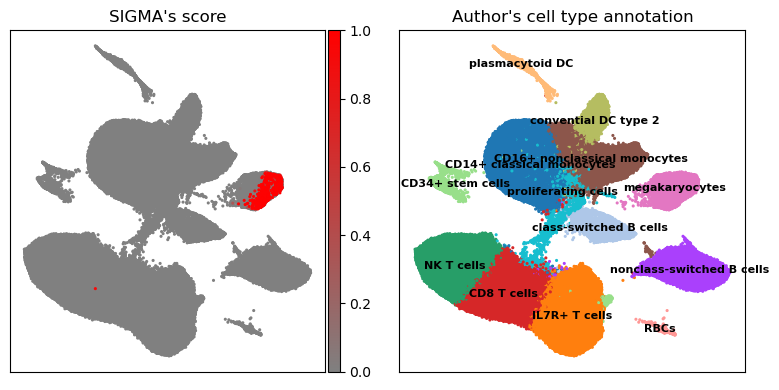

In [6]:
import scanpy as sc

fig, ax = plt.subplots(ncols=2, figsize=(8, 4))

sc.pl.umap(
    adata_sumry,
    s=20,
    title="Author's cell type annotation",
    color="celltype",
    ax=ax[1],
    legend_loc="on data",
    legend_fontsize=8,
    show=False,
)

# tracer les points triés par score pour que les plus hauts soient dessinés en dernier (au 1er plan)
order = np.argsort(adata_sumry.obs["score"].values)  # ascendant -> les plus grands seront à la fin
adata_sorted = adata_sumry[order]
sc.pl.umap(adata_sorted, s=20, title="SIGMA's score", color="score", cmap=gray_to_red,
           vmin=0, vmax=1, ax=ax[0], show=False)

for a in ax:
    a.set_xlabel("")
    a.set_ylabel("")
    a.tick_params(labelbottom=False, labelleft=False)
    a.set_xticklabels([])
    a.set_yticklabels([])

plt.tight_layout()
# fig.savefig("figures/SIGMAvsCLUSTER.png", format='png', bbox_inches='tight', dpi=300)
# fig.savefig("figures/fortman_SIGMAvsCLUSTER.svg", bbox_inches='tight', dpi=300)
fig.savefig("figures/fortman_SIGMAvsCLUSTER.tiff", bbox_inches='tight', dpi=300)
plt.show()

# Why author's MK are not found by SIGMA

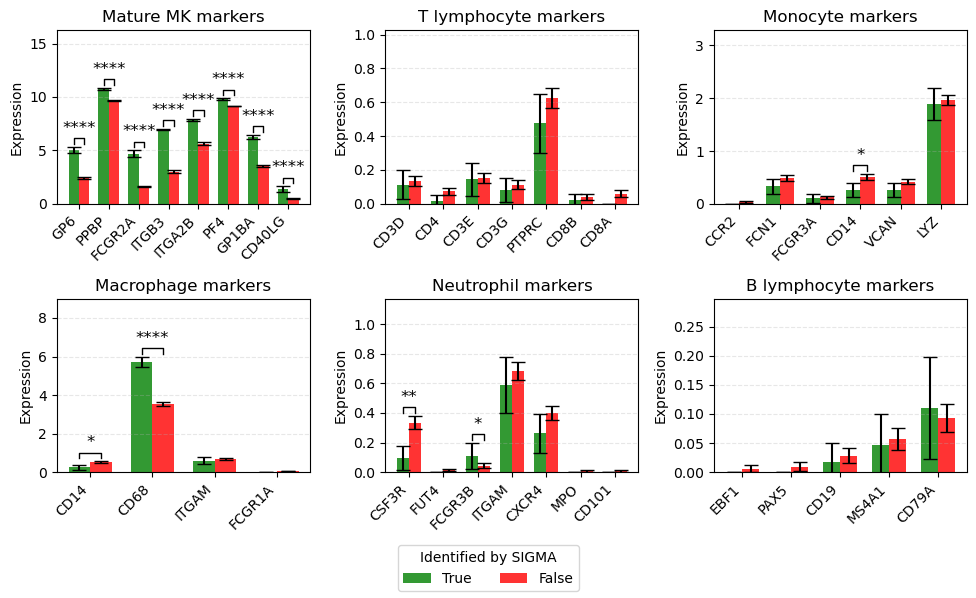

In [7]:
mk_mature = ['GP6', 'PPBP', 'FCGR2A', 'ITGB3', 'ITGA2B', 'PF4', 'GP1BA', 'CD40LG']
Tlympho = ['CD3D', 'CD4', 'CD3E', 'CD3G', 'PTPRC', 'CD8B', 'CD8A']
mono = ['CCR2', 'FCN1', 'FCGR3A', 'CD14', 'VCAN', 'LYZ']
macro = ['CD14', 'CD68', 'ITGAM', 'FCGR1A']
neutro = ['CSF3R', 'FUT4', 'FCGR3B', 'ITGAM', 'CXCR4', 'MPO', 'CD101']
Blympho = ['EBF1', 'PAX5', 'CD19', 'MS4A1', 'CD79A']

fig, ax = plt.subplots(2, 3, figsize=(10, 6))

plot_gene_expression_summary(mk_author, mk_mature, "Identified by SIGMA", title="Mature MK markers", ax=ax[0,0])
plot_gene_expression_summary(mk_author, Tlympho, "Identified by SIGMA", title="T lymphocyte markers", ax=ax[0,1])
plot_gene_expression_summary(mk_author, mono, "Identified by SIGMA", title="Monocyte markers", ax=ax[0,2])
plot_gene_expression_summary(mk_author, macro, "Identified by SIGMA", title="Macrophage markers", ax=ax[1,0])
plot_gene_expression_summary(mk_author, neutro, "Identified by SIGMA", title="Neutrophil markers", ax=ax[1,1])
plot_gene_expression_summary(mk_author, Blympho, "Identified by SIGMA", title="B lymphocyte markers", ax=ax[1,2])

# build a common legend from the first axis and remove per-axis legends
handles, labels = ax[0,0].get_legend_handles_labels()
for a in ax.ravel():
    a.legend_.remove()

fig.legend(handles, labels, loc='lower center', ncol=2, title='Identified by SIGMA')
plt.tight_layout(rect=[0, 0.08, 1, 1])

fig.savefig('figures/fortman_LineageExpression.svg', bbox_inches="tight", dpi=300)
plt.show()

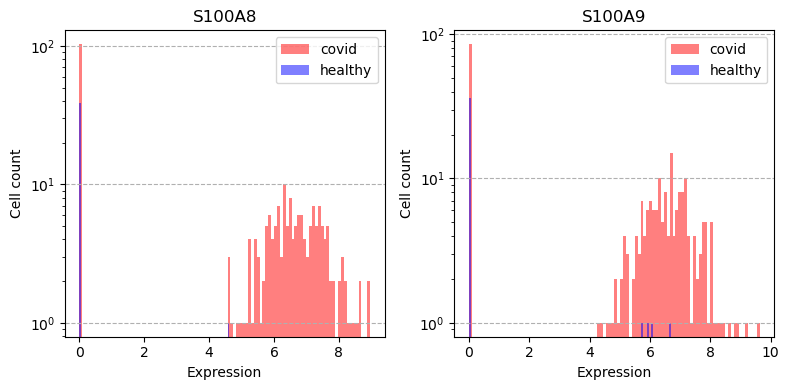

In [8]:
s100 = mk_sigma.to_df()[["S100A8", "S100A9"]]

fig, ax = plt.subplots(1, 2, figsize=(8, 4))

disease = adata_author.obs.loc[s100.index, "disease"]
s100_covid = s100[disease == "covid"]
s100_healthy = s100[disease == "healthy"]

ax[0].hist(s100_covid["S100A8"].values.flatten(), bins=100, alpha=0.5, color='red', label='covid')
ax[0].hist(s100_healthy["S100A8"].values.flatten(), bins=100, alpha=0.5, color='blue', label='healthy')
ax[0].set_title("S100A8")
ax[0].set_xlabel("Expression")
ax[0].set_ylabel("Cell count")
ax[0].set_yscale("log")
ax[0].grid(axis='y', linestyle='--')
ax[0].legend()

ax[1].hist(s100_covid["S100A9"].values.flatten(), bins=100, alpha=0.5, color='red', label='covid')
ax[1].hist(s100_healthy["S100A9"].values.flatten(), bins=100, alpha=0.5, color='blue', label='healthy')
ax[1].set_title("S100A9")
ax[1].set_xlabel("Expression")
ax[1].set_ylabel("Cell count")
ax[1].set_yscale("log")
ax[1].grid(axis='y', linestyle='--')
ax[1].legend()

plt.tight_layout()
fig.savefig('figures/fortman_S100A8-9.svg', bbox_inches="tight", dpi=300)
plt.show()